In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL

Loading the data and getting familiar with it.

In [2]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = pd.read_csv(data_path)

df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03
mean,145.515545,146.681738,144.471597,145.617278,5.773301e+06
std,37.554946,37.613446,37.477641,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.405000,117.765000,115.490000,116.525000,3.622681e+06
50%,149.610000,150.330000,148.470000,149.315000,4.928852e+06
75%,178.445000,179.762500,177.330000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


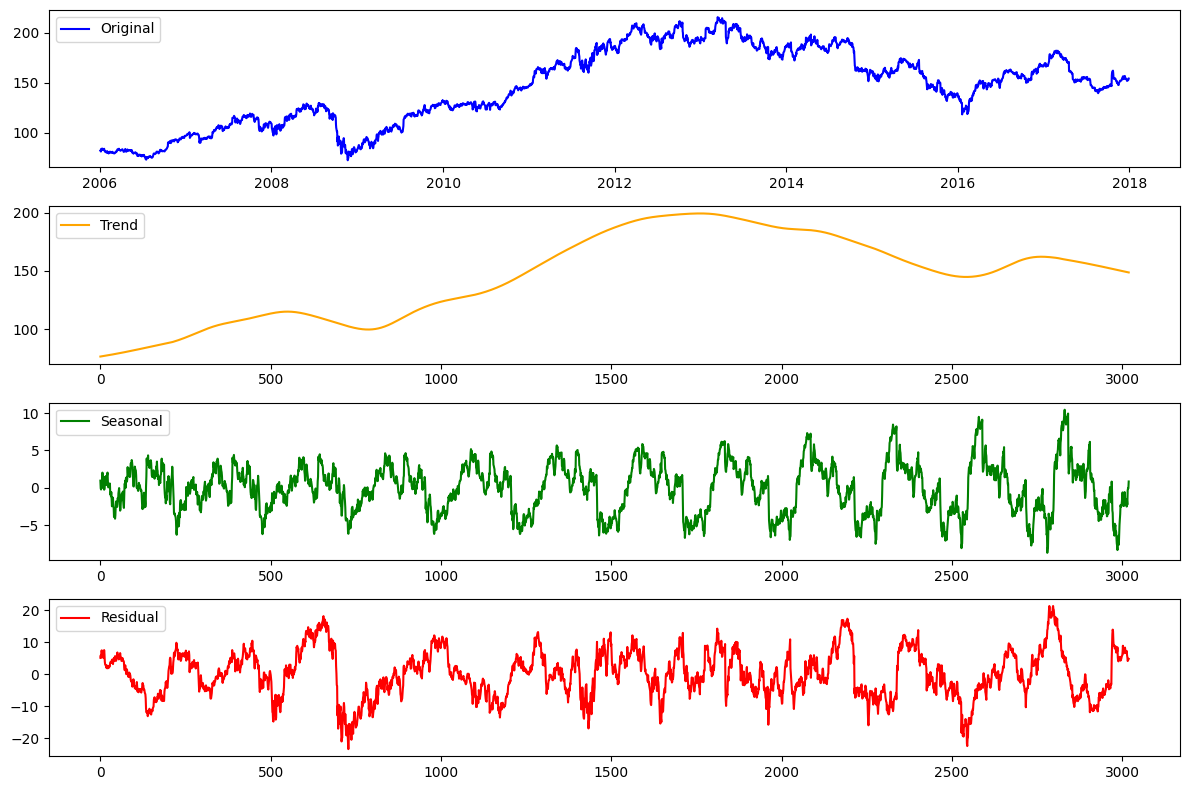

In [ ]:
# drop missing values and provide an explicit period so STL doesn't need to infer it from the index
dates = pd.to_datetime(df['Date'])
series = df["Open"]

series = series.dropna()
dates = dates[series.index]

stl = STL(series, period=252, seasonal=17)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(dates, series, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(dates, trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(dates, seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(dates, resid, label='Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()